In [1]:
import numpy as np

from two_layer_net import TwoLayerNet

In [2]:
net = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

In [3]:
x = np.random.rand(100, 784)
y = net.predict(x)

In [4]:
x = np.random.rand(100, 784)
t = np.random.rand(100, 10)

grads = net.numerical_gradient(x, t)

print(grads['W1'].shape)
print(grads['b1'].shape)
print(grads['W2'].shape)
print(grads['b2'].shape)

(784, 50)
(50,)
(50, 10)
(10,)


In [17]:
from dataset.mnist import load_mnist

In [24]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)
train_loss_list = []

In [25]:
iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

In [26]:
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

In [27]:
for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)

    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grads[key]

    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

In [28]:
import matplotlib.pyplot as plt

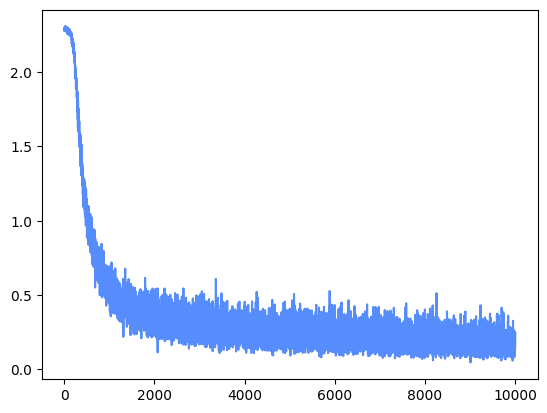

In [29]:
plt.plot(train_loss_list)

In [63]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)
network = TwoLayerNet(input_size=784, hidden_size=1000, output_size=10)

In [64]:
iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

In [65]:
train_loss_list = []
train_acc_list = []
test_acc_list = []

In [66]:
iter_per_epoch = max(train_size / batch_size, 1)

In [67]:
for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grad = network.gradient(x_batch, t_batch)

    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ",\t" + str(test_acc))

train acc, test acc | 0.09863333333333334,	0.0958
train acc, test acc | 0.8022666666666667,	0.809
train acc, test acc | 0.88535,	0.8924
train acc, test acc | 0.9011166666666667,	0.905
train acc, test acc | 0.9063166666666667,	0.9087
train acc, test acc | 0.9089333333333334,	0.913
train acc, test acc | 0.9130666666666667,	0.9169
train acc, test acc | 0.91495,	0.9165
train acc, test acc | 0.9136166666666666,	0.9158
train acc, test acc | 0.9142666666666667,	0.9159
train acc, test acc | 0.91905,	0.9215
train acc, test acc | 0.9197333333333333,	0.9201
train acc, test acc | 0.92225,	0.9215
train acc, test acc | 0.9238666666666666,	0.9237
train acc, test acc | 0.9234666666666667,	0.9248
train acc, test acc | 0.92185,	0.9238
train acc, test acc | 0.9270166666666667,	0.9234


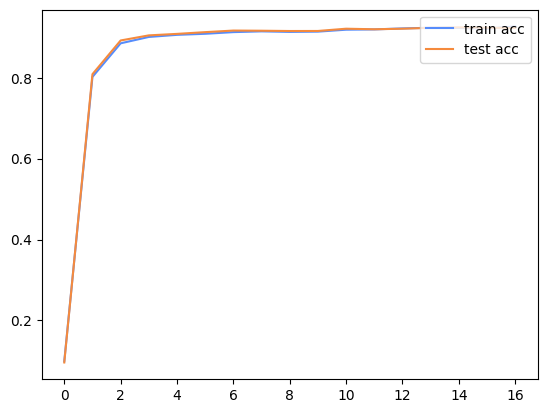

In [68]:
plt.plot(train_acc_list, label='train acc')
plt.plot(test_acc_list, label='test acc')
plt.legend(loc='upper right')